# Premières architectures de LeCun

In [1]:
import torch
import torch.nn as nn

In [2]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
# --- Utilitaire : courbe de perte train/val en direct ---
# Aucune installation nécessaire : matplotlib + IPython sont déjà dans le kernel.
import matplotlib.pyplot as plt
from IPython.display import clear_output


def live_plot_losses(history, title="Entraînement", xlabel="Epoch"):
    """Trace (et met à jour en direct) les courbes de perte train / val.

    history : dict de listes, p.ex. {"train_loss": [...], "val_loss": [...]}.
              Les clés "train_acc" / "val_acc" sont optionnelles et ajoutent
              un second panneau "accuracy".
    À appeler à la fin de chaque epoch : le graphe se redessine sur place,
    et la courbe finale reste affichée une fois l'entraînement terminé.
    """
    clear_output(wait=True)  # efface le graphe précédent -> effet "temps réel"
    has_acc = "train_acc" in history
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, ax = plt.subplots(1, 2 if has_acc else 1,
                           figsize=(12 if has_acc else 7, 4.5), squeeze=False)
    ax = ax[0]

    ax[0].plot(epochs, history["train_loss"], marker=".", label="Train")
    if history.get("val_loss"):
        ax[0].plot(epochs, history["val_loss"], marker=".", label="Val")
    ax[0].set(xlabel=xlabel, ylabel="Loss", title=f"{title} — Loss")
    ax[0].legend(); ax[0].grid(True, alpha=0.3)

    if has_acc:
        ax[1].plot(epochs, history["train_acc"], marker=".", label="Train")
        if history.get("val_acc"):
            ax[1].plot(epochs, history["val_acc"], marker=".", label="Val")
        ax[1].set(xlabel=xlabel, ylabel="Accuracy (%)", title=f"{title} — Accuracy")
        ax[1].legend(); ax[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

In [4]:
class LeNet1989(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet1989, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5)      # 1x28x28 -> 4x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 4x24x24 -> 4x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(4, 12, kernel_size=5)     # 4x12x12 -> 12x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 12x8x8 -> 12x4x4

        # Fully connected
        self.fc1   = nn.Linear(12*4*4, 60)
        self.fc2   = nn.Linear(60, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)   # logits
        return x


In [5]:
model = LeNet1989()
model

LeNet1989(
  (conv1): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(4, 12, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=192, out_features=60, bias=True)
  (fc2): Linear(in_features=60, out_features=10, bias=True)
)

In [6]:
class LeNet5(nn.Module):  # 1998
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)      # 1x28x28 -> 6x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 6x24x24 -> 6x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)     # 6x12x12 -> 16x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 16x8x8 -> 16x4x4

        # Fully connected
        self.fc1   = nn.Linear(16*4*4, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # logits
        return x


In [7]:
model = LeNet5()
model

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

# La convolution

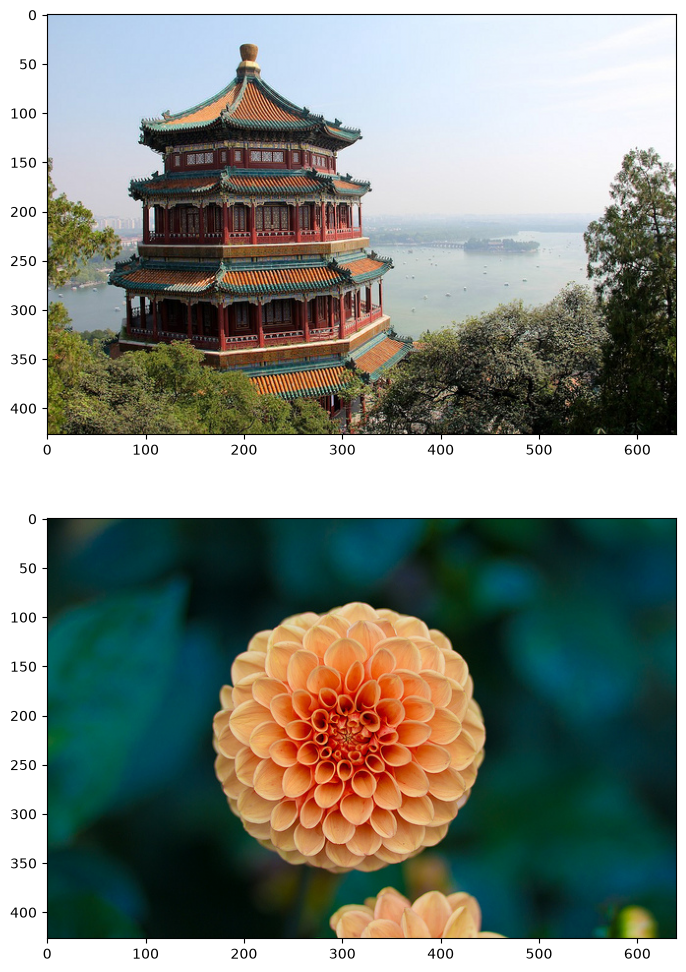

In [8]:
import numpy as np
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt

# Load sample images
china = load_sample_image("china.jpg") / 255.
flower = load_sample_image("flower.jpg") / 255.

fig, ax = plt.subplots(2, 1, figsize=(15, 12))
ax[0].imshow(china)
ax[1].imshow(flower)

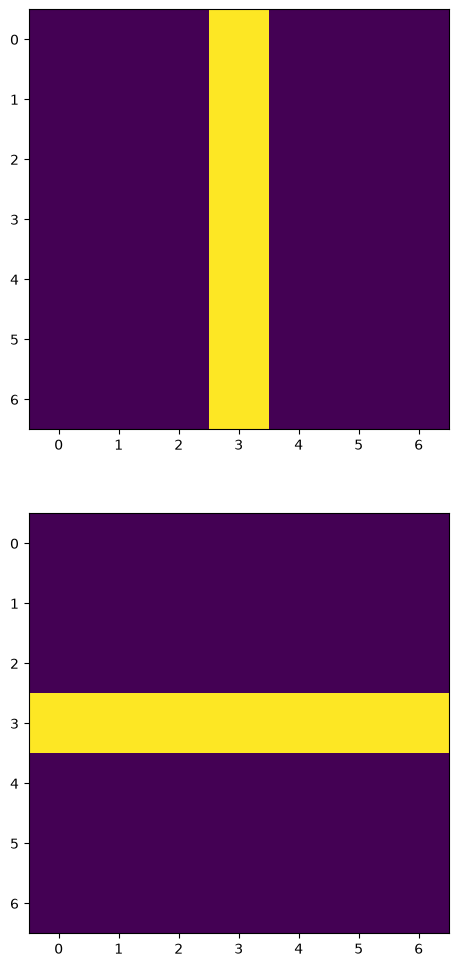

In [9]:
# Create a batch of images
images = np.array([china, flower])
batch_size, height, width, channels = images.shape

# Create 2 filters: one vertical and one horizontal
filters = np.zeros(shape=(2, channels, 7, 7), dtype=np.float32)
filters[0, :, :, 3] = 1  # vertical line
filters[1, :, 3, :] = 1  # horizontal line

fig, ax = plt.subplots(2, 1, figsize=(15, 12))
ax[0].imshow(filters[0, 0, :, :])
ax[1].imshow(filters[1, 0, :, :])

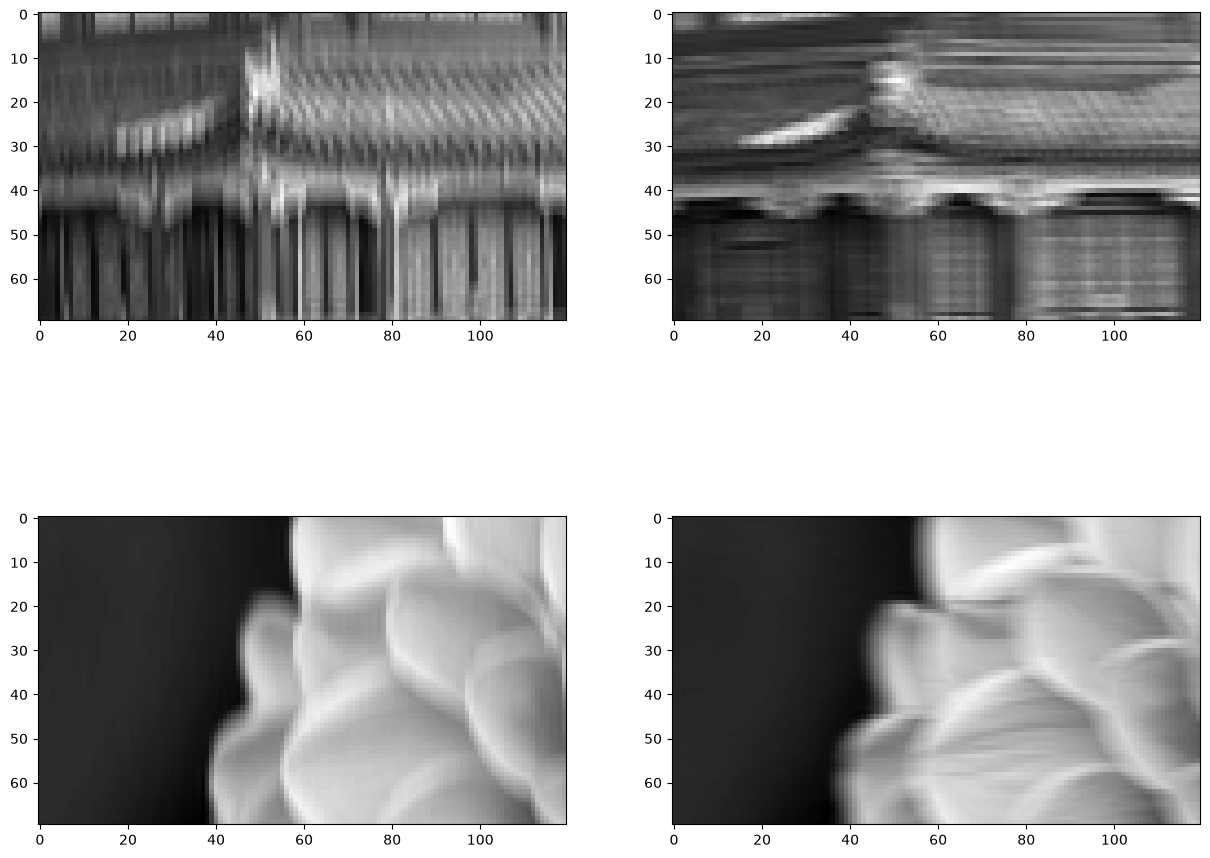

In [10]:
conv_layers = torch.nn.Conv2d(in_channels=3, out_channels=2, kernel_size=7, stride=1, padding="same")
conv_layers.weight = torch.nn.Parameter(torch.tensor(filters))

outputs = conv_layers(torch.tensor(images, dtype=torch.float32).permute([0, 3, 1 ,2])).detach()

def crop(images):
    return images[150:220, 130:250]


fig, ax = plt.subplots(2, 2, figsize=(15, 12))

ax[0, 0].imshow(crop(outputs[0, 0, :, :]), cmap='gray')
ax[0, 1].imshow(crop(outputs[0, 1, :, :]), cmap='gray')

ax[1, 0].imshow(crop(outputs[1, 0, :, :]), cmap='gray')
ax[1, 1].imshow(crop(outputs[1, 1, :, :]), cmap='gray')

# Exercice modification LeNet-5
Modifier afin d'intégrer le GlobalAvgPooling et vérifier les formats de sorties des 2 modèles sur une image au format native et une autre non native

In [11]:
x_natif = torch.randn((1, 1, 28, 28))  # Format natif
x_other = torch.randn((1, 1, 256, 512))  # Format non natif

In [12]:
class LeNet5_GAP(nn.Module): 
    def __init__(self, num_classes=10):
        super(LeNet5_GAP, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)      # 1x28x28 -> 6x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 6x24x24 -> 6x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)     # 6x12x12 -> 16x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 16x8x8 -> 16x4x4

        # Fully connected
        self.fc1   = nn.Linear(16, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.mean(x, dim=(2, 3))
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # logits
        return x


In [13]:
lenet5 = LeNet5(10)
lenet5_gap = LeNet5_GAP(10)

print(lenet5(x_natif).shape)
print(lenet5_gap(x_natif).shape)

torch.Size([1, 10])
torch.Size([1, 10])


In [14]:
print(lenet5_gap(x_other).shape)
print(lenet5(x_other).shape)  #-> erreur

torch.Size([1, 10])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x122000 and 256x120)

### Exercice : Voir architecture MLP utiliser sur MNIST et comparer le nombre de paramètres entre MLP et CNN ainsi que les performances entre les deux

In [15]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype("int64") 

from torch.utils.data import Dataset

class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32) / 255.
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne une paire (image, label)
        return self.X[idx], self.y[idx]

dataset = MNISTDataset(X, y)

In [16]:
class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers, num_classes):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(n_neurons, num_classes)

    def forward(self, x):
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        logits = self.output_layer(h)   # logits bruts (attendus par CrossEntropyLoss)
        return logits

    def predict_proba(self, x):
        # Probabilités (softmax) — pour l'inférence, PAS pour la loss
        return nn.Softmax(dim=1)(self.forward(x))

In [17]:
mlp_mnist_classifier = MLP(in_shape=X.shape[1], n_neurons=64, num_hiddens_layers=1, num_classes=10).to(device)
# mlp_mnist_classifier est déjà défini ci-dessus
total_params = sum(p.numel() for p in mlp_mnist_classifier.parameters())
trainable_params = sum(p.numel() for p in mlp_mnist_classifier.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 55050
Trainable parameters: 55050


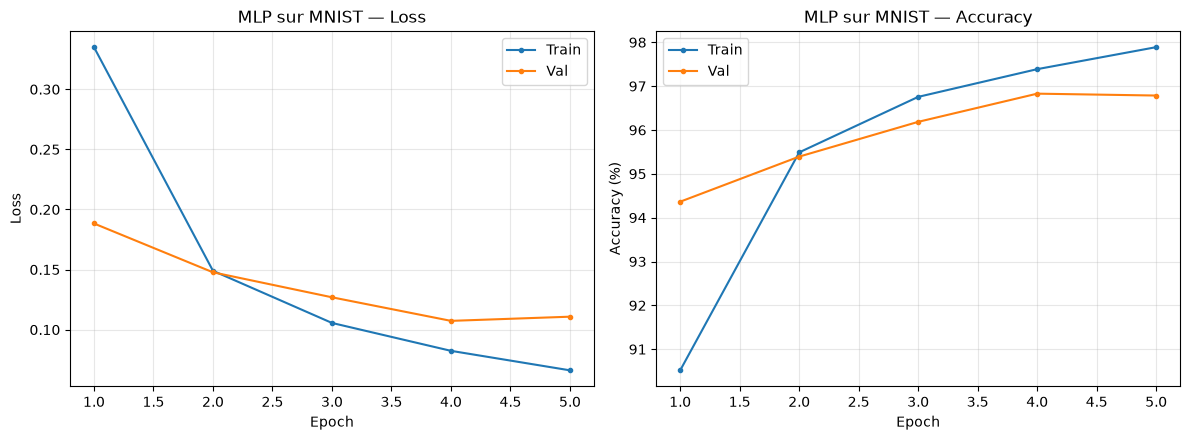

In [18]:
# Optimiseur et loss
from torch.utils.data import DataLoader, random_split
learning_rate = 1e-3
optimizer = torch.optim.Adam(mlp_mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
# Split train / validation (80 / 20)
n_val = int(0.2 * len(dataset))
train_dataset, val_dataset = random_split(dataset, [len(dataset) - n_val, n_val])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Entraînement
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
n_epochs = 5
for epoch in range(1, n_epochs+1):
    total_loss = 0
    correct = 0
    total = 0
    mlp_mnist_classifier.train()
    for xb, yb in train_dataloader:  # Mini-Batch
        y_pred = mlp_mnist_classifier(xb.to(device))
        loss = criterion(y_pred, yb.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(y_pred.cpu(), dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total

    # --- Validation ---
    mlp_mnist_classifier.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in val_dataloader:
            y_pred = mlp_mnist_classifier(xb.to(device))
            loss = criterion(y_pred, yb.to(device))
            val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(y_pred.cpu(), dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total

    # Historique + courbe train/val en direct (remplace le print)
    history["train_loss"].append(epoch_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_acc)
    history["val_acc"].append(epoch_val_acc)
    live_plot_losses(history, title="MLP sur MNIST")

In [19]:
cnn_mnist_classifier = LeNet5_GAP(num_classes=10).to(device)

total_params = sum(p.numel() for p in cnn_mnist_classifier.parameters())
trainable_params = sum(p.numel() for p in cnn_mnist_classifier.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 15626
Trainable parameters: 15626


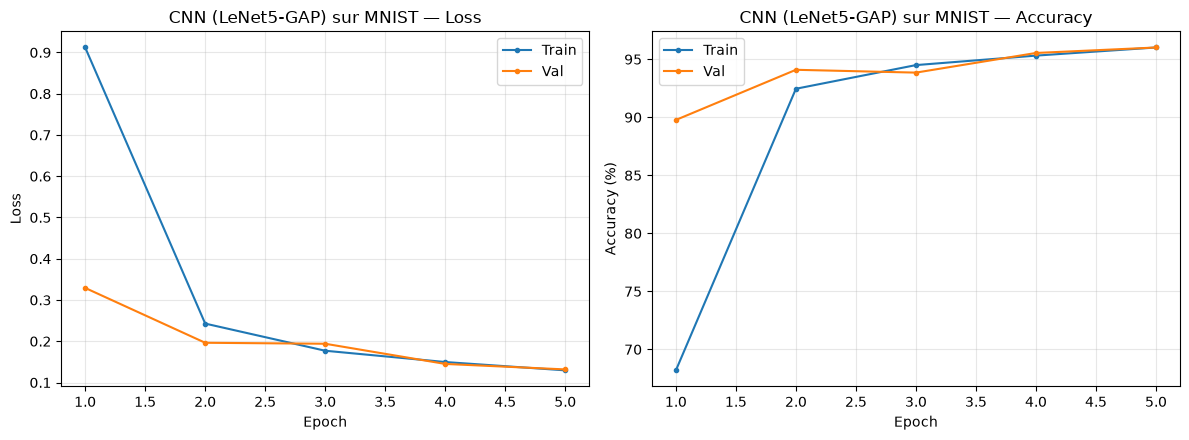

In [20]:
from torch.utils.data import Dataset, DataLoader, random_split

class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne une paire (image, label)
        return self.X[idx], self.y[idx]


# Optimiseur et loss
learning_rate = 1e-3
optimizer = torch.optim.Adam(cnn_mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
dataset = MNISTDataset(X, y)
# Split train / validation (80 / 20)
n_val = int(0.2 * len(dataset))
train_dataset, val_dataset = random_split(dataset, [len(dataset) - n_val, n_val])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Entraînement
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
n_epochs = 5
for epoch in range(1, n_epochs+1):
    total_loss = 0
    correct = 0
    total = 0
    cnn_mnist_classifier.train()
    for xb, yb in train_dataloader:  # Mini-Batch
        y_pred = cnn_mnist_classifier(xb.to(device))
        loss = criterion(y_pred, yb.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(y_pred.cpu(), dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total

    # --- Validation ---
    cnn_mnist_classifier.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in val_dataloader:
            y_pred = cnn_mnist_classifier(xb.to(device))
            loss = criterion(y_pred, yb.to(device))
            val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(y_pred.cpu(), dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = 100 * val_correct / val_total

    history["train_loss"].append(epoch_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_acc)
    history["val_acc"].append(epoch_val_acc)
    live_plot_losses(history, title="CNN (LeNet5-GAP) sur MNIST")

#### Avec moins de paramètres pour le CNN on obtient de meilleures performances que sur MLP

# Transfer Learning
Comparer un modèle pré-entrainé à un modèle from scratch

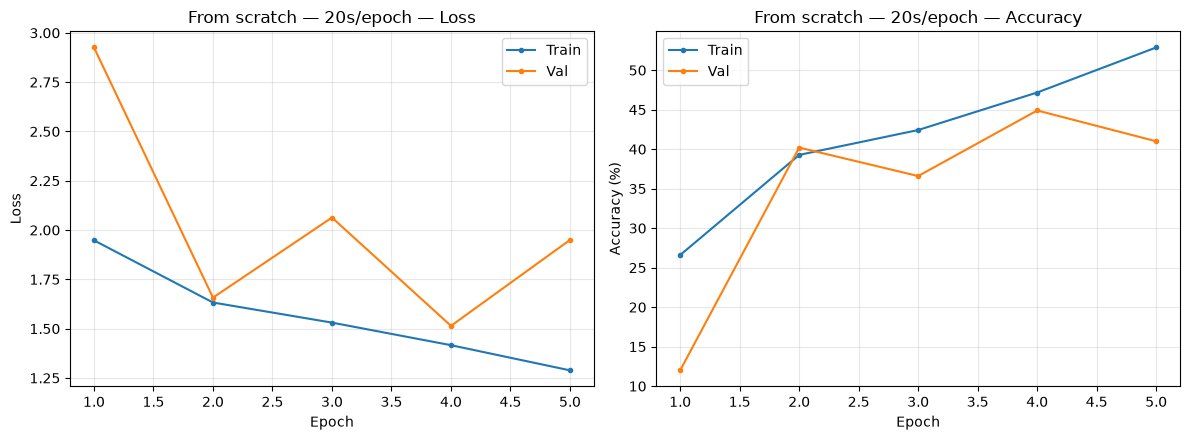

Test Accuracy: 0.4159


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
import time
import numpy as np

# ===========================
# Hyperparamètres
# ===========================
batch_size = 64
num_classes = 10
num_epochs = 5
learning_rate = 0.001
subset_fraction = 0.1  # 10% du dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# Dataset & DataLoader
# ===========================
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_full = datasets.CIFAR10(root='../datasets/cifar_data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='../datasets/cifar_data', train=False, download=True, transform=transform_test)

# On ne garde qu'une fraction du dataset pour accentuer l'effet transfer learning
subset_size = int(len(train_dataset_full) * subset_fraction)
subset_indices = np.random.choice(len(train_dataset_full), subset_size, replace=False)
train_dataset = Subset(train_dataset_full, subset_indices)

# Split train / validation (80 / 20) pour suivre la courbe de validation
n_val = int(0.2 * len(train_dataset))
n_train = len(train_dataset) - n_val
train_subset, val_subset = random_split(train_dataset, [n_train, n_val])

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# ===========================
# Fonctions d'entraînement et d'évaluation
# ===========================
def train_model(model, criterion, optimizer, num_epochs, val_loader=None, title="Entraînement"):
    model = model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(100 * correct / total)

        # --- Validation ---
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * images.size(0)
                    _, predicted = outputs.max(1)
                    val_total += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()
            history["val_loss"].append(val_loss / val_total)
            history["val_acc"].append(100 * val_correct / val_total)

        # Courbe train/val en direct (remplace le print par epoch)
        live_plot_losses(history, title=f"{title} — {time.time()-start_time:.0f}s/epoch")
    return history

def evaluate_model(model):
    model.eval()
    model = model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = correct / total
    print(f"Test Accuracy: {acc:.4f}")
    return acc

# ===========================
# 1) Model from scratch
# ===========================
print("=== Training from scratch (10% dataset) ===")
model_scratch = models.mobilenet_v2(weights=None)
model_scratch.classifier[1] = nn.Linear(model_scratch.last_channel, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=learning_rate)

train_model(model_scratch, criterion, optimizer, num_epochs, val_loader, title="From scratch")
acc_scratch = evaluate_model(model_scratch)

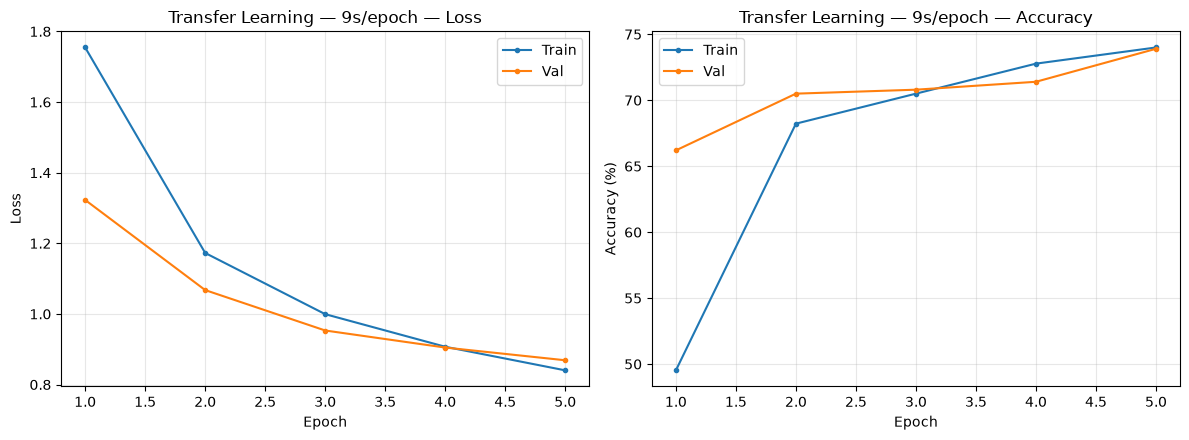

Test Accuracy: 0.7148

Accuracy from scratch: 0.4159
Accuracy with transfer learning: 0.7148


In [22]:
# ===========================
# 2) Transfer Learning
# ===========================
print("\n=== Transfer Learning (10% dataset) ===")
model_tl = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for param in model_tl.features.parameters():
    param.requires_grad = False  # gèle les couches convolutives

model_tl.classifier[1] = nn.Linear(model_tl.last_channel, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tl.classifier.parameters(), lr=learning_rate)

train_model(model_tl, criterion, optimizer, num_epochs, val_loader, title="Transfer Learning")
acc_tl = evaluate_model(model_tl)

print(f"\nAccuracy from scratch: {acc_scratch:.4f}")
print(f"Accuracy with transfer learning: {acc_tl:.4f}")

## Exercice : Autoencodeur de débruitage d'images (FashionMNIST)

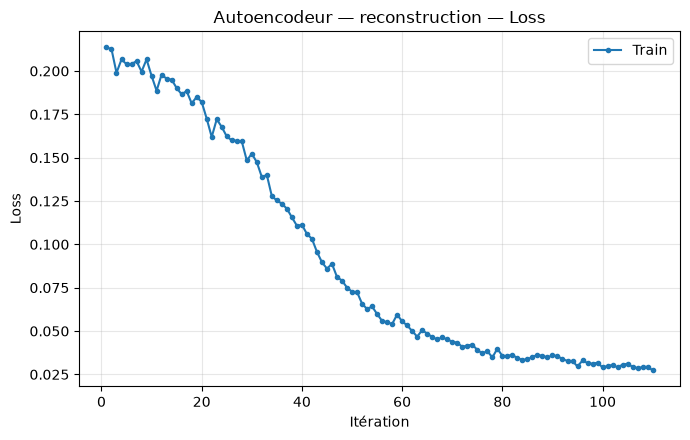

In [23]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# --- 1. Dataset avec bruit gaussien ---
class NoisyFashionMNIST(Dataset):
    def __init__(self, train=True, noise_std=0.3):
        self.dataset = torchvision.datasets.FashionMNIST(
            root="../datasets", train=train, download=True, transform=transforms.ToTensor()
        )
        self.noise_std = noise_std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]   # img: [1,28,28], valeurs [0,1]
        noisy_img = img + torch.randn_like(img) * self.noise_std
        noisy_img = torch.clamp(noisy_img, 0., 1.)  # garder dans [0,1]
        return noisy_img, img  # x = bruité, y = original

# --- 2. Dataloader ---
train_dataset = NoisyFashionMNIST(train=True)
test_dataset  = NoisyFashionMNIST(train=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# --- 3. Autoencodeur convolutionnel simple ---
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid()  # pour rester dans [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# --- 4. Exemple d'entraînement ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Boucle d'entraînement rapide. Une seule epoch suffit.
# On trace la perte de reconstruction par itération (mini-batch).
history = {"train_loss": []}
count = 0
for epoch in range(1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        history["train_loss"].append(loss.item())
        count += 1
        if count % 10 == 0:  # redessine la courbe toutes les 10 itérations
            live_plot_losses(history, title="Autoencodeur — reconstruction", xlabel="Itération")
        if count == 110:  # L'augmenter de 10 en 10 en exécutant la cellule d'après pour voir l'évolution
            break
    live_plot_losses(history, title="Autoencodeur — reconstruction", xlabel="Itération")

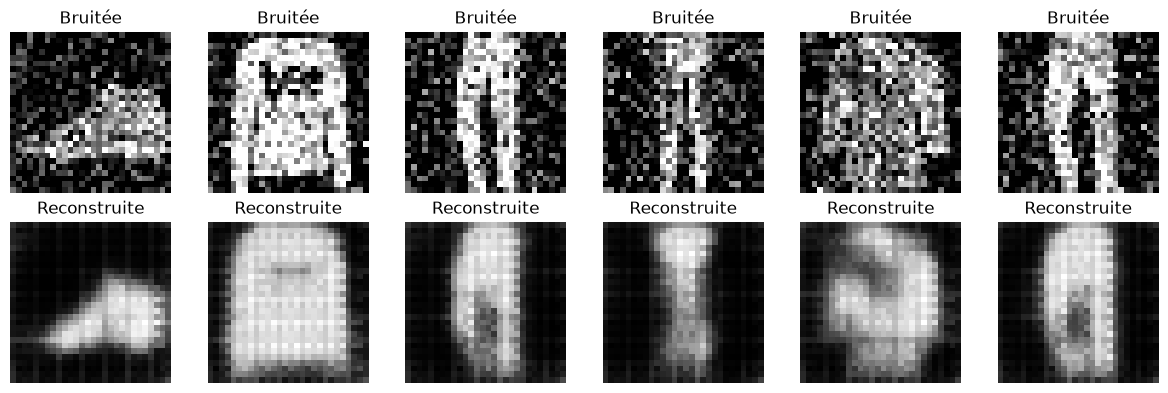

In [24]:
import matplotlib.pyplot as plt
import torch

# Assurer que le modèle est en mode évaluation
model.eval()

# Récupérer un batch de test
x_batch, y_batch = next(iter(test_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

# Prédiction du modèle
with torch.no_grad():
    y_pred = model(x_batch)

# Visualisation des 6 premières images
n = 6
plt.figure(figsize=(12, 4))
for i in range(n):
    # Image bruitée
    plt.subplot(2, n, i+1)
    plt.imshow(x_batch[i].cpu().squeeze(), cmap='gray')
    plt.title("Bruitée")
    plt.axis('off')
    
    # Image reconstruite
    plt.subplot(2, n, i+1+n)
    plt.imshow(y_pred[i].cpu().squeeze(), cmap='gray')
    plt.title("Reconstruite")
    plt.axis('off')

plt.tight_layout()
plt.show()


### Exercice : Détection d’anomalie

Étape 3 : Estimation de la distribution normale...
Distribution calculée. Forme du tenseur moyen : torch.Size([256, 14, 14])
Étape 4 : Inférence sur une image de test...


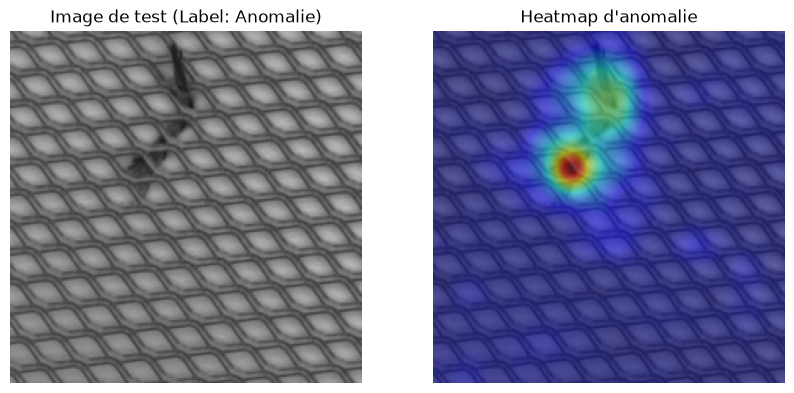

In [25]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
BATCH_SIZE = 16

# =====================================================================
# ÉTAPE 1 : Le Dataset MVTec (CORRIGÉ)
# =====================================================================
class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, is_train=True, transform=None):
        self.root_dir = root_dir
        self.category = category
        self.is_train = is_train
        self.transform = transform
        
        self.image_paths = []
        self.labels = [] 
        
        self._load_dataset()

    def _load_dataset(self):
        category_dir = os.path.join(self.root_dir, self.category)
        
        if self.is_train:
            # Train contient uniquement des images saines ('good')
            good_images = glob.glob(os.path.join(category_dir, "train", "good", "*.png"))
            self.image_paths.extend(good_images)
            self.labels.extend([0] * len(good_images))
        else:
            # Test contient 'good' (sains = 0) et plusieurs types de défauts (anomalies = 1)
            test_dir = os.path.join(category_dir, "test")
            subfolders = os.listdir(test_dir)
            
            for folder in subfolders:
                folder_path = os.path.join(test_dir, folder)
                if not os.path.isdir(folder_path):
                    continue
                
                images = glob.glob(os.path.join(folder_path, "*.png"))
                self.image_paths.extend(images)
                
                if folder == "good":
                    self.labels.extend([0] * len(images))
                else:
                    self.labels.extend([1] * len(images))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Lecture en RGB pour s'aligner sur les canaux attendus par ImageNet
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Transformations standards ImageNet
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# =====================================================================
# ÉTAPE 2 : Extracteur de Features (CORRIGÉ)
# =====================================================================
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # Chargement des poids mis à jour selon l'API récente de torchvision
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Un ResNet18 possède 10 enfants principaux. 
        # Les indices 0 à 6 correspondent à : conv1, bn1, relu, maxpool, layer1, layer2, layer3.
        # On exclut layer4 (trop de perte de résolution spatiale) et les couches de classification.
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:7])
        
        # Freeze des gradients pour l'inférence stricte
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
            
        self.eval()

    def forward(self, x):
        return self.feature_extractor(x)


# =====================================================================
# ÉTAPE 3 : Modélisation de la Normalité (Train) - CORRIGÉ
# =====================================================================
def train_distribution(feature_extractor, train_loader):
    feature_extractor.eval()
    all_features = []
    
    with torch.no_grad():
        for images, _ in train_loader:
            images = images.to(DEVICE)
            features = feature_extractor(images)
            all_features.append(features.cpu())
            
    # Concaténation sur la dimension du batch -> [N, C, H, W]
    all_features = torch.cat(all_features, dim=0)
    
    # Estimation empirique par pixel-position (dim=0 calcule les stats à travers le batch N)
    mean = all_features.mean(dim=0)
    var = all_features.var(dim=0, unbiased=False)
    
    return mean, var


# =====================================================================
# ÉTAPE 4 : Inférence et Génération de la Heatmap (CORRIGÉ)
# =====================================================================
def predict_anomaly_map(feature_extractor, test_image, mean, var, epsilon=1e-5):
    feature_extractor.eval()
    with torch.no_grad():
        test_feat = feature_extractor(test_image)
    
    test_feat = test_feat.squeeze(0).cpu() # [C, H_feat, W_feat]
    
    # Calcul de Mahalanobis diagonale : sqrt( sum( (x - mu)^2 / var ) )
    # On somme sur la dimension des canaux (dim=0)
    anomaly_map = torch.sqrt(torch.sum(((test_feat - mean) ** 2) / (var + epsilon), dim=0))
    
    # Préparation pour F.interpolate -> requiert [B, C, H, W]
    anomaly_map = anomaly_map.unsqueeze(0).unsqueeze(0)
    
    # Upsampling bilinéaire vers la résolution d'origine
    anomaly_map_resized = F.interpolate(
        anomaly_map, 
        size=(IMAGE_SIZE, IMAGE_SIZE), 
        mode='bilinear', 
        align_corners=False
    )
    
    # Extraction du tenseur 2D natif
    anomaly_map_resized = anomaly_map_resized.squeeze().numpy()
    
    # Filtrage gaussien spatial pour adoucir les contours de la carte thermique
    anomaly_map_smoothed = gaussian_filter(anomaly_map_resized, sigma=4)
    
    return anomaly_map_smoothed


# =====================================================================
# SCRIPT PRINCIPAL DE VÉRIFICATION
# =====================================================================
if __name__ == "__main__":
    # Remplace par ton arborescence locale si nécessaire
    DATA_PATH = "../datasets/anomaly_detection" 
    CATEGORY = "grid"
    
    train_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=False, transform=transform)
    
    extractor = FeatureExtractor().to(DEVICE)
    
    print("Étape 3 : Estimation de la distribution normale...")
    mean, var = train_distribution(extractor, train_loader)
    print(f"Distribution calculée. Forme du tenseur moyen : {mean.shape}") # Attendu: [256, 14, 14] pour ResNet18/Layer3
    
    print("Étape 4 : Inférence sur une image de test...")
    # Sélection d'une image anormale à des fins de démonstration visuelle
    anomaly_indices = [i for i, label in enumerate(test_dataset.labels) if label == 1]
    if len(anomaly_indices) > 0:
        sample_idx = anomaly_indices[np.random.randint(0, len(anomaly_indices))]
    else:
        sample_idx = np.random.randint(0, len(test_dataset))
        
    img_tensor, label = test_dataset[sample_idx]
    
    heatmap = predict_anomaly_map(extractor, img_tensor.unsqueeze(0).to(DEVICE), mean, var)
    
    # Post-traitement de l'image pour affichage Matplotlib
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    orig_img = inv_normalize(img_tensor).permute(1, 2, 0).clip(0, 1).numpy()
    
    # Tracé
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Image de test (Label: {'Anomalie' if label == 1 else 'Sain'})")
    plt.imshow(orig_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Heatmap d'anomalie")
    plt.imshow(orig_img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5) 
    plt.axis('off')
    plt.show()

### Exercice modèle multimodale

In [26]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from os.path import join
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from torchvision.io import read_image

In [27]:
class FlipkartDataset(Dataset):
    def __init__(self):
        self.metadata = pd.read_csv('../datasets/Flipkart/flipkart_com-ecommerce_sample_1050.csv')

        # Text data
        vectorizer = CountVectorizer()
        self.x_texts = torch.tensor(vectorizer.fit_transform(self.metadata['description'].values).todense(), dtype=torch.float32)
        self.x_texts /= self.x_texts.max()


        # Image data
        self.x_images = []
        images_path = '../datasets/Flipkart/Images'
        for image_filename in self.metadata['image'].tolist():
            image_tensor = torch.nn.Upsample(size=(1080, 1080))(read_image(join(images_path, image_filename)).unsqueeze(0)) / 255.
            self.x_images.append(image_tensor)
        self.x_images = torch.cat(self.x_images, dim=0)

        # Label data
        self.y = self.metadata['product_category_tree'].apply(lambda x: x.split(' >> ')[0][2:])
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y)
        
    def __len__(self):
        return len(self.x_images)

    def __getitem__(self, idx):
        return self.x_images[idx], self.x_texts[idx], self.y[idx]

In [28]:
batch_size = 2

dataset = FlipkartDataset()
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

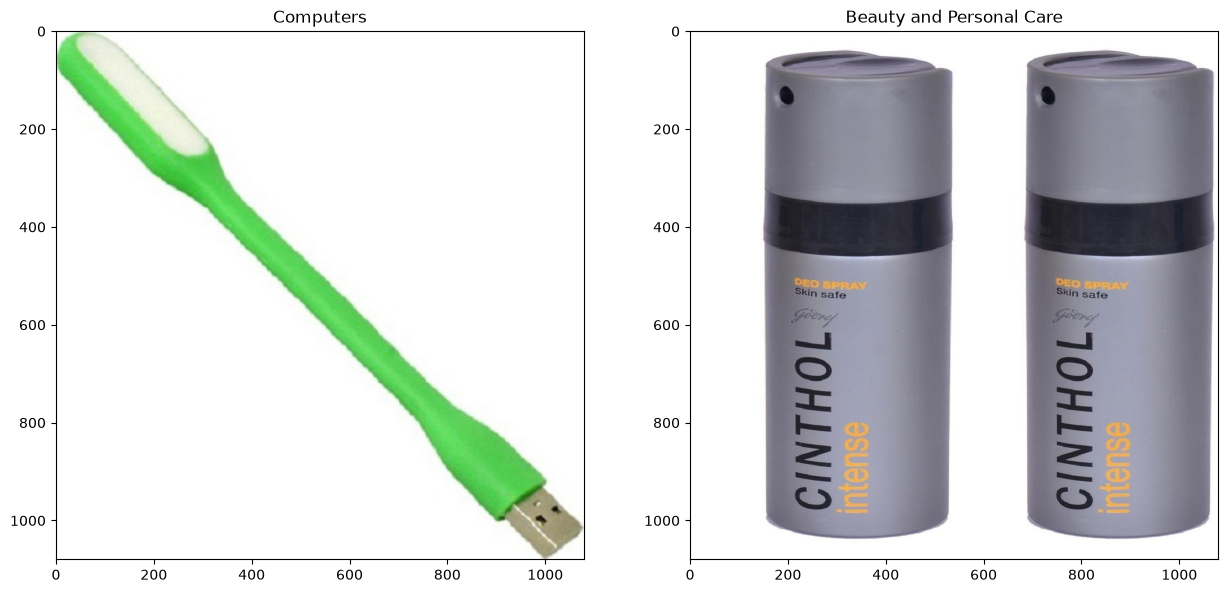

In [29]:
# A relancer plusieurs fois
fig, axs = plt.subplots(batch_size//2, 2)

fig.set_size_inches(15, 15)
axs = axs.ravel()

for images, _, y in dataloader:
    y = dataset.le.inverse_transform(y)
    for i in range(batch_size):
        axs[i].imshow(images[i].permute([1, 2, 0]))
        axs[i].set_title(y[i])
    break


In [30]:
dataset.le.classes_

array(['Baby Care', 'Beauty and Personal Care', 'Computers',
       'Home Decor & Festive Needs', 'Home Furnishing',
       'Kitchen & Dining', 'Watches'], dtype=object)

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridModel(nn.Module):
    def __init__(self, text_dim=6053, num_classes=7):
        super(HybridModel, self).__init__()
        
        # --- Text branch ---
        self.text_fc = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        
        # --- Image branch ---
        self.img_conv = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=5, stride=2, padding=2),  # (8, 540, 540)
            nn.ReLU(),
            nn.MaxPool2d(2),                                       # (8, 270, 270)
            
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1), # (16, 135, 135)
            nn.ReLU(),
            nn.MaxPool2d(2),                                       # (16, 67, 67)
        )
        
        # Flatten conv output → project to 256-dim embedding
        conv_out_dim = 16 * 67 * 67
        self.img_fc = nn.Sequential(
            nn.Linear(conv_out_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        
        # --- Fusion & classification ---
        self.classifier = nn.Sequential(
            nn.Linear(64 + 64, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, text_x, img_x):
        # text_x: (batch, 6053)
        # img_x:  (batch, 3, 1080, 1080)
        
        text_feat = self.text_fc(text_x)  # (batch, 64)
        
        img_feat = self.img_conv(img_x)
        img_feat = img_feat.view(img_feat.size(0), -1)  # flatten
        img_feat = self.img_fc(img_feat)                # (batch, 64)
        
        fused = torch.cat([text_feat, img_feat], dim=1)  # (batch, 64+64)
        out = self.classifier(fused)                     # (batch, 7)
        return out


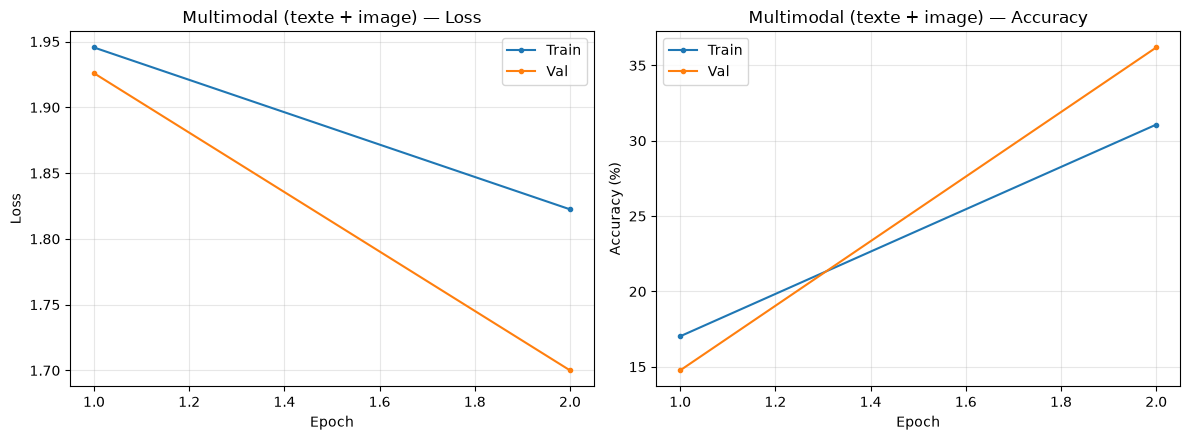

In [32]:
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score
import numpy as np

# --- Hyperparameters ---
BATCH_SIZE = 2
LR = 1e-4
EPOCHS = 2
PATIENCE = 5  # early stopping patience
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Très lent en CPU

# --- Dataset / DataLoader ---
dataset = FlipkartDataset()

val_ratio = 0.2
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Model, Loss, Optimizer ---
model = HybridModel().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# --- Training Loop with Early Stopping ---
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    train_preds, train_targets = [], []

    for x_img, x_txt, y in train_loader:
        y = y.long()
        x_img, x_txt, y = x_img.to(DEVICE), x_txt.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x_txt.float(), x_img.float())
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_preds.append(out.argmax(dim=1).cpu())
        train_targets.append(y.cpu())

    train_preds = torch.cat(train_preds)
    train_targets = torch.cat(train_targets)
    train_acc = accuracy_score(train_targets, train_preds)

    # --- Validation ---
    model.eval()
    val_losses = []
    val_preds, val_targets = [], []
    with torch.no_grad():
        for x_img, x_txt, y in val_loader:
            y = y.long()
            x_img, x_txt, y = x_img.to(DEVICE), x_txt.to(DEVICE), y.to(DEVICE)
            out = model(x_txt.float(), x_img.float())
            loss = criterion(out, y)
            val_losses.append(loss.item())
            val_preds.append(out.argmax(dim=1).cpu())
            val_targets.append(y.cpu())

    val_preds = torch.cat(val_preds)
    val_targets = torch.cat(val_targets)
    val_acc = accuracy_score(val_targets, val_preds)

    # Historique + courbe train/val en direct (remplace le print par epoch)
    history["train_loss"].append(np.mean(train_losses))
    history["val_loss"].append(np.mean(val_losses))
    history["train_acc"].append(100 * train_acc)
    history["val_acc"].append(100 * val_acc)
    live_plot_losses(history, title="Multimodal (texte + image)")

    # --- Early stopping ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # torch.save(model.state_dict(), "best_hybrid_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# # --- Load best model ---
# model.load_state_dict(torch.load("best_hybrid_model.pth"))
# print("Training finished. Best validation accuracy:", best_val_acc)